# Compute statistics on scores

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ir_rpp.preprocessing import load_labels_and_runs, dataset_summary
from ir_rpp.scores import evaluate_preferences, aggregate_preferences, get_ordering
from ir_rpp.statistical_tests import (
    run_ttests,
    run_tukeys_hsd_test,
    run_kendal_tau,
    run_tau_ordering_comparison,
    plot_metric_correlations,
)

from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

## Datasets (Table 1)

In [2]:
qrels, runs = load_labels_and_runs("deep-pass",2020, binary_relevance=1)

Reading run files: 100%|██████████| 59/59 [00:06<00:00,  8.56it/s]


In [3]:
dataset_summary(qrels, runs)

requests             54.0
runs                 59.0
rel/request           0.0
subtopics/request     1.0
dtype: float64

## Compute preferences and orderings

In [4]:
ALL_METRICS = [
    "rpp",
    "invrpp",
    "dcgrpp",
    "ap",
    "ndcg",
    "rr",
]  # TODO: complete with others like ASL

In [8]:
summary, preferences, raw_metrics = evaluate_preferences(
    runs=runs, measures=ALL_METRICS, query_eval_wanted=True
)

Iterating over qids:   0%|          | 0/54 [00:00<?, ?it/s]

In [10]:
pref_eval_output = summary + preferences + raw_metrics
system_orderings_by_query, system_orderings = aggregate_preferences(
    pref_eval_output=pref_eval_output, query_eval_wanted=True,
)

## Correlation with existing metrics

### Correlation of query-level metric differences (Figure 5)

Note that it was originally done on `Robust` dataset. 

Note that for now metrics `ASL`, `OI` and `dcgOI` are missing. - TODO

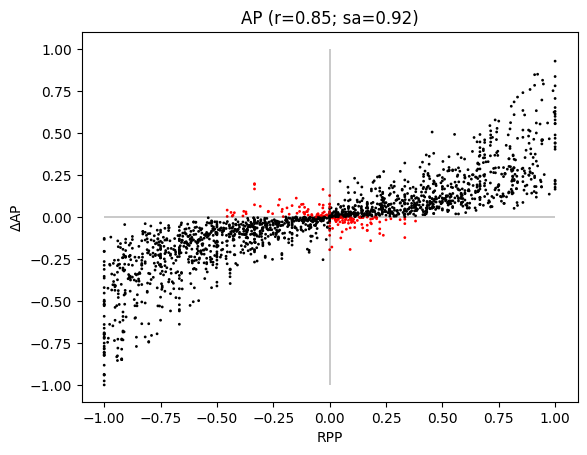

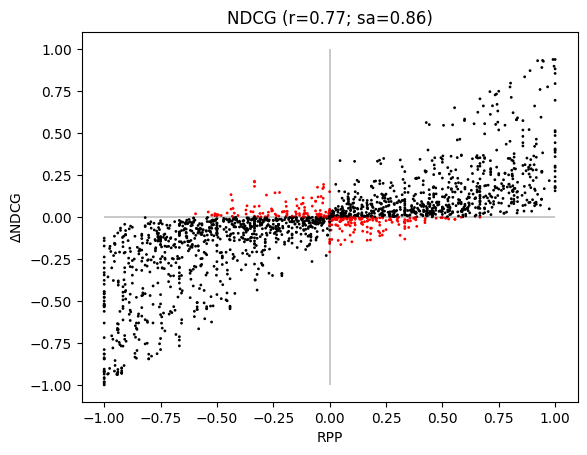

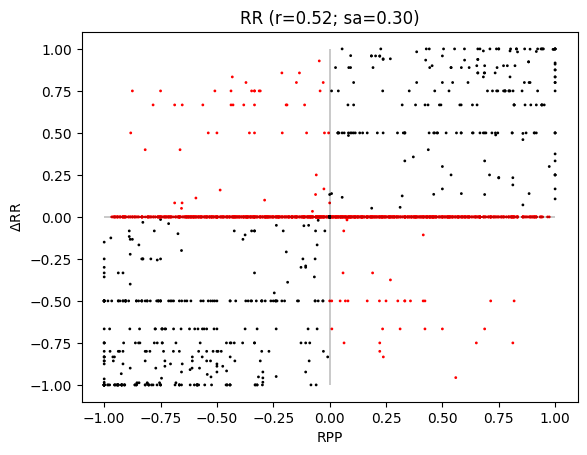

In [11]:
plot_metric_correlations(preferences, ALL_METRICS, nb_queries=None, nb_prefs=2000)

### Compare orderings with Kendall's tau (Table 2)

Note that correlations are higher than in Table 2a since it's only for one dataset and e.g. `LibraryThing` is RecSys result, having few runs ans a lot of requests, so on average metrics may agree more.

Note that we need to obtain such data frames for all datasets and average them.

In [12]:
run_tau_ordering_comparison(system_orderings, system_orderings_by_query, query_id=None)

,invrpp,rpp,dcgrpp,ap,ndcg
rr,0.706604,0.632963,0.661017,0.650497,0.574518
invrpp,NaN,0.888954,0.931034,0.880771,0.760374
rpp,NaN,NaN,0.94623,0.895967,0.831677
dcgrpp,NaN,NaN,NaN,0.905319,0.805961
ap,NaN,NaN,NaN,NaN,0.856224


## Robustness to incomplete data

### Missing requests (Figure 6)

In [14]:
QUERY_FRACTIONS = np.linspace(0.05, 0.95, 20)
NUM_SAMPLES = 1 # TODO: bug if NUM_SAMPLES=2
missing_queries_orderings = {}
for query_fraction in tqdm(QUERY_FRACTIONS):
    missing_queries_orderings[float(query_fraction)] = aggregate_preferences(
        pref_eval_output=pref_eval_output,
        query_eval_wanted=False,
        query_fraction=query_fraction,
        num_samples=NUM_SAMPLES,
    )[1]

  0%|          | 0/20 [00:00<?, ?it/s]

In [15]:
missing_queries_tau = {}
for metric in ALL_METRICS:
    missing_queries_tau[metric] = []
    for query_fraction in QUERY_FRACTIONS:
        # TODO: agglomerate across samples
        tau, _ = run_kendal_tau(
            get_ordering(missing_queries_orderings[float(query_fraction)], metric),
            get_ordering(system_orderings, metric),
        )
        missing_queries_tau[metric].append(tau)

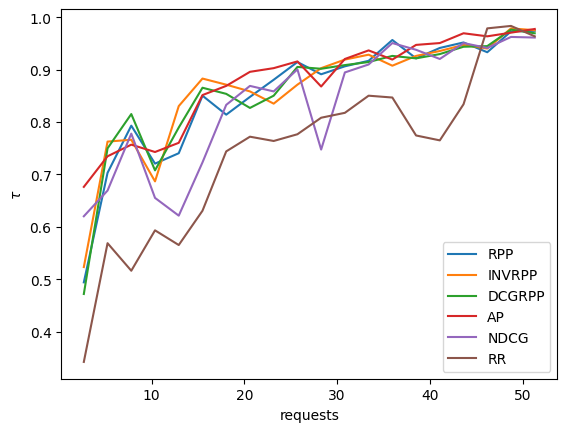

In [16]:
for metric in ALL_METRICS:
    plt.plot(
        [fraction * len(qrels) for fraction in QUERY_FRACTIONS],
        missing_queries_tau[metric],
        label=metric.upper(),
    )
plt.legend()
plt.xlabel("requests")
plt.ylabel("$\\tau$")
plt.show()

### Missing judgement labels (Figure 7)

In [ ]:
# TODO

## Discriminative Power

### t-test with Bonferroni (Table 4a)

In [17]:
df_ttest, df_summary = run_ttests(preferences)
df_summary

metric,rpp,dcgrpp,invrpp,ap,ndcg,rr
significant,46.28872,50.146113,52.250146,39.976622,31.618936,19.053185


### Tukey's HSD test (Table 3a)

Algorithm implemented from *Carterette, Benjamin A. “Multiple Testing in Statistical Analysis of Systems-Based Information Retrieval Experiments.” ACM Trans. Inf. Syst. 30, no. 1 (2012): 4:1-4:34. https://doi.org/10.1145/2094072.2094076.*


In [18]:
# NOTE: takes forever
# TODO: verify the algorithm implementation
df_ttest_hsd, df_summary_hsd = run_tukeys_hsd_test(preferences)
df_summary_hsd

Comparing Pairs: 100%|██████████| 1711/1711 [00:00<00:00, 311708.04it/s]


metric,rpp,dcgrpp,invrpp,ap,ndcg,rr
significant,37.64,39.28,39.45,29.81,17.59,20.34
